# Some visualizations for the data we collected on each model

### Implementation
I will start by getting all the metrics for each model in a function and then I will plot them side by side for the user to see

I will use the same features and train test splits so as to get a proper comparsion

### Metrics to be used
- f1 score
- Measn squared error
- Confusion matrix variables. True Positives, True negatives, Fasle Positives, False Negatives
- Features that were relied on the most and the least

### Importing Libraries to be used

In [73]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
# from sklearn.inspection import permutation_importance
# import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, classification_report, r2_score,mean_squared_error

### Importing the different m,odels form files my colleagues and I have worked on

In [ ]:
%store -r y_pred_dt y_pred_rf gbc_pred knn_base_pred mlp_pred  mlp_balanced_pred 
%store -r dt_cm rf_cm gbc_cm knn_base_cm mlp_cm mlp_balanced_cm
#dt - Decision Tree
# rf -  Random Forest
# mlp - Multilayer perceptron
# knn - K- Nearest neighbour Classification
# 
modelsToTest = {
    "DT" : y_pred_dt,
    "RF" :y_pred_rf,
    "GBC":gbc_pred,
    "KNN":knn_base_pred,
    "MLP":mlp_pred,
    "MLP_B":mlp_balanced_pred,
    # "AutoML":AutoML_pred
}

confusion_matri = [
    "DT":dt_cm,
    "RF":rf_cm,
    "GBC":gbc_cm,
    "KNN":knn_base_cm, 
    "MLP":mlp_cm ,
    "MLP_B":mlp_balanced_cm,
]

In [ ]:
# Collecting the data Set 

script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#Stating the features will the cycle time removed 
features = [
    'ZSx [s]',        # injection time
    'ACPx [cm³]',     # cushion volume
    'ZDx [s]',        # dosing time
            # cycle time  'ZUs [s]', 
    'ZEx [s]',        # (keep if it’s meaningful in your process)
    'GEx [kWh]',      # energy consumption

    'H16x [°C]',    # temperature 1
    'H10x [°C]',       # temperature 2
]
# {'DT': 0.041666666666666664, 'RF': 0.027777777777777776, 'GBC': 0.5084745762711864, 'KNN': 0.9367088607594937, 'MLP': 0.8611111111111112, 'MLP_B': 0.8780487804878049}
# features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'APHu [bar]', 'GEx [kWh]', 'GPx [kW]', 'HPx [kW]', 'HEx [kWh]', 'MPx [kW]', 'ESPx [kWh/kg]', 'H16x [°C]', 'H15x [°C]', 'H10x [°C]', 'H12x [°C]', 'H9x [°C]', 'H11x [°C]']

#Separating the features from the target
X = dataset[features].copy()
y = dataset['ASZ [Sch]'].astype(int).copy()

# getting the train and test splits 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  And finally scaling as done in all other files
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### The next function will ttake in the models one by one and run some metrics in order for me to easily graph and compare the models.

In [76]:
def get_f1_score(y_test,y_pred):
    return f1_score(y_test,y_pred)

def get_r2_score(y_test,y_pred):
    
    return r2_score(y_test,y_pred)

def get_mean_squared_error(y_test,y_pred):
   
    return mean_squared_error(y_test,y_pred)

def get_true_positives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[0][0]

def get_false_Negatives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[0][1]

def get_false_positives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[1][0] 

def get_true_negatives_from_c_matrix(y_test, y_pred):
    return confusion_matrix(y_test, y_pred)[1][1]

def get_classification_report(y_test,y_pred):
    return classification_report(y_test,y_pred,output_dict=True)



## Trying a different Approach where instead import the classification matrix of the model and give the two F1 Scores for when it guessed it to be true and when It guessed it to be false

In [ ]:
%store dt_rep 

### Finally the main function that will Run through the models and produce the things necessary to plot the models against each other

In [77]:
predictions = {}
f1_scores = {}
r2_scores = {}
mean_squared_errors = {}
#from confusion matrix
true_positives = {}
false_negatives = {}
false_positives = {}
true_negatives = {}
#from classification report
recall = {}
support = {}
precision = {}
accuracy = {}
weighted_avg = {}
macro_avg = {}

def fill_data():

    for n_model, model_pred in modelsToTest.items():
        # ---  Incase we choose to fit and predict the models ---
        # model.fit(X_train_scaled,y_train)
        # predictions[n_model] = model.predict(X_test_scaled)
        predictions[n_model] = model_pred
        
        
    for n_model , pred in predictions.items():
        f1_scores[n_model] = get_f1_score(y_test=y_test,y_pred=pred)
        r2_scores[n_model] = get_r2_score(y_test=y_test,y_pred=pred)
        mean_squared_errors[n_model] = get_mean_squared_error(y_test=y_test,y_pred=pred)
        true_positives[n_model] = get_true_positives_from_c_matrix(y_test=y_test,y_pred=pred)
        false_negatives[n_model] = get_false_Negatives_from_c_matrix(y_test=y_test,y_pred=pred)
        false_positives[n_model] = get_false_positives_from_c_matrix(y_test=y_test,y_pred=pred)
        true_negatives[n_model] = get_true_negatives_from_c_matrix(y_test=y_test,y_pred=pred)
        recall[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['recall']
        support[n_model] = get_classification_report(y_test=y_test,y_pred=pred)['0']['support']
        precision[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['precision']
        accuracy[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['accuracy']
        # weighted_avg[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['weighted']
        # macro_avg[n_model] =get_classification_report(y_test=y_test,y_pred=pred)['0']['macro_avg']

    
    return {
    "F1_Scores":f1_scores,
    "R2_Scores":r2_scores,
    "MSE":mean_squared_errors,
    "True_Positives":true_positives,
    "True_Negatives":true_negatives,
    "False_Negatives":false_negatives,
    "False_Positives":false_positives,
    "recall":recall,
    "support":support,
    "precision":precision,
    "accuracy":accuracy,
    # "weighted_avg":weighted_avg,
    # "macro_avg":macro_avg,

}
    

### Now I make relevant plots in the main function

In [78]:

def main():
    for m_name,metric in fill_data().items():
        nnames = list(metric.keys())
        values = list(metric.values())
        print(m_name)
        print(metric)

        plt.figure()
        plt.bar(nnames, values)

        plt.xlabel("Model")
        plt.ylabel("Value")
        plt.title(f"{m_name}")

        plt.show()

### Run the main function to show the plotted data

F1_Scores
{'DT': 0.07352941176470588, 'RF': 0.06976744186046512, 'GBC': 0.5084745762711864, 'KNN': 0.9367088607594937, 'MLP': 0.8611111111111112, 'MLP_B': 0.8780487804878049}


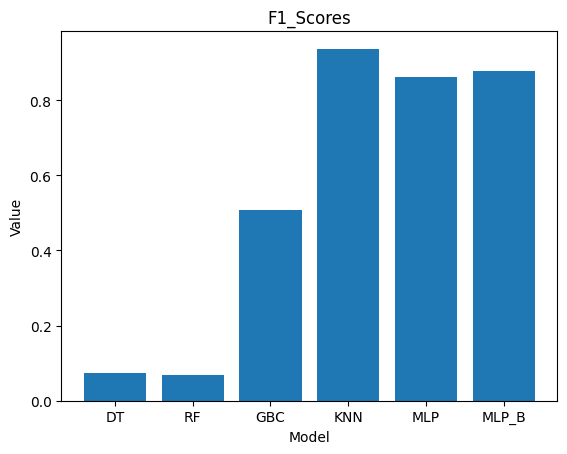

R2_Scores
{'DT': -2.450837705195465, 'RF': -1.1910080667907712, 'GBC': 0.20575957578834536, 'KNN': 0.8630619958255767, 'MLP': 0.7261239916511536, 'MLP_B': 0.7261239916511536}


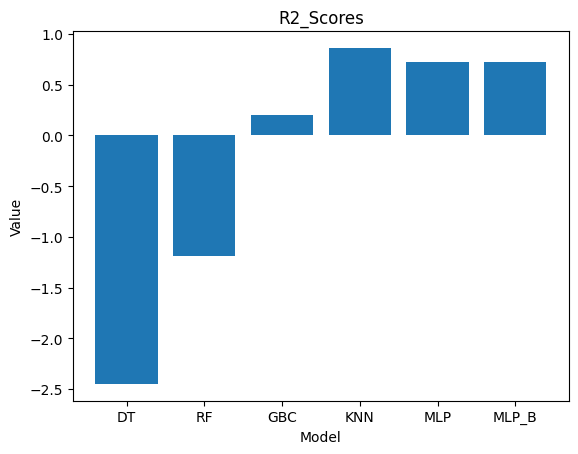

MSE
{'DT': 0.12976313079299692, 'RF': 0.082389289392379, 'GBC': 0.029866117404737384, 'KNN': 0.005149330587023687, 'MLP': 0.010298661174047374, 'MLP_B': 0.010298661174047374}


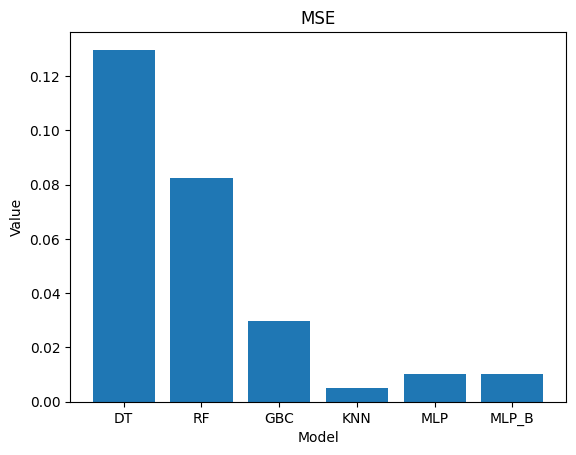

True_Positives
{'DT': np.int64(840), 'RF': np.int64(888), 'GBC': np.int64(927), 'KNN': np.int64(929), 'MLP': np.int64(930), 'MLP_B': np.int64(925)}


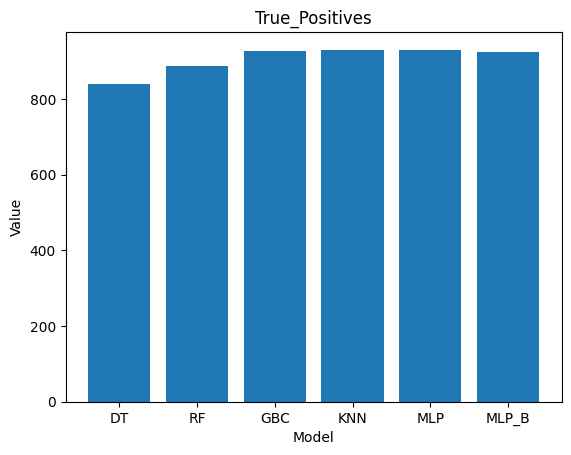

True_Negatives
{'DT': np.int64(5), 'RF': np.int64(3), 'GBC': np.int64(15), 'KNN': np.int64(37), 'MLP': np.int64(31), 'MLP_B': np.int64(36)}


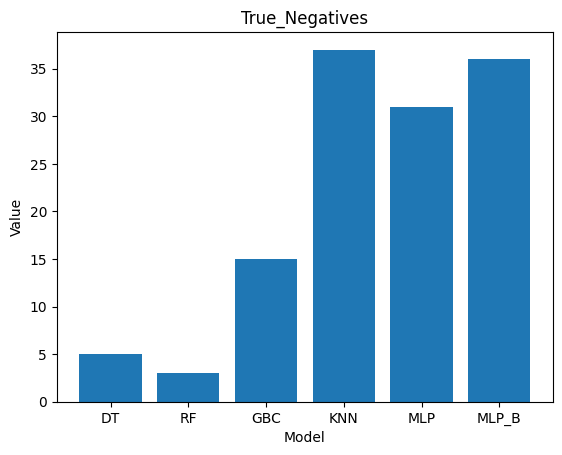

False_Negatives
{'DT': np.int64(93), 'RF': np.int64(45), 'GBC': np.int64(6), 'KNN': np.int64(4), 'MLP': np.int64(3), 'MLP_B': np.int64(8)}


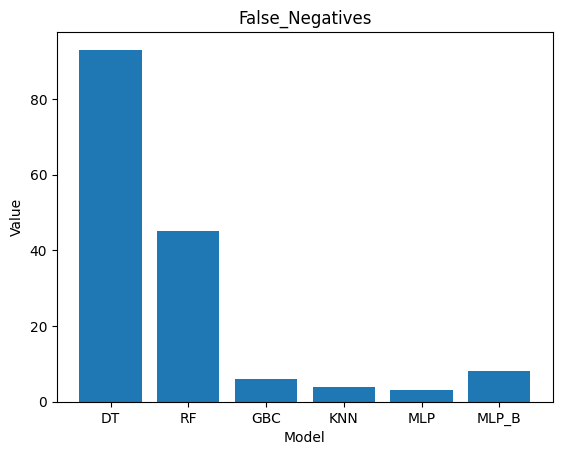

False_Positives
{'DT': np.int64(33), 'RF': np.int64(35), 'GBC': np.int64(23), 'KNN': np.int64(1), 'MLP': np.int64(7), 'MLP_B': np.int64(2)}


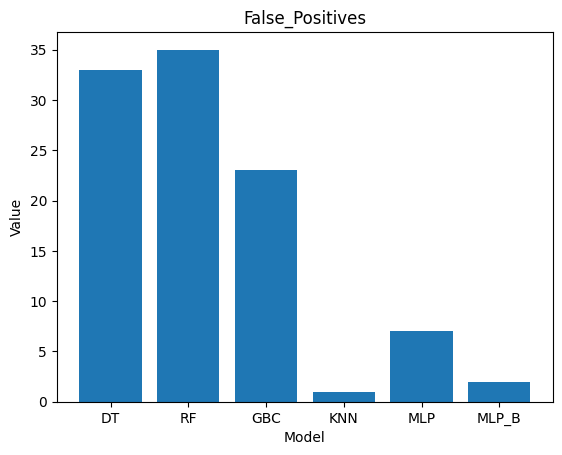

recall
{'DT': 0.9003215434083601, 'RF': 0.9517684887459807, 'GBC': 0.9935691318327974, 'KNN': 0.9957127545551983, 'MLP': 0.9967845659163987, 'MLP_B': 0.9914255091103966}


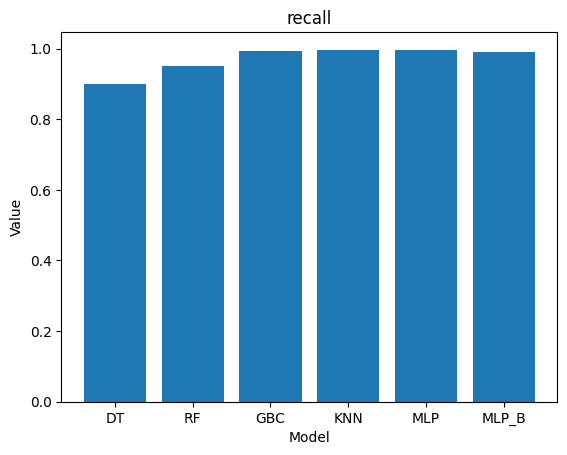

support
{'DT': 933.0, 'RF': 933.0, 'GBC': 933.0, 'KNN': 933.0, 'MLP': 933.0, 'MLP_B': 933.0}


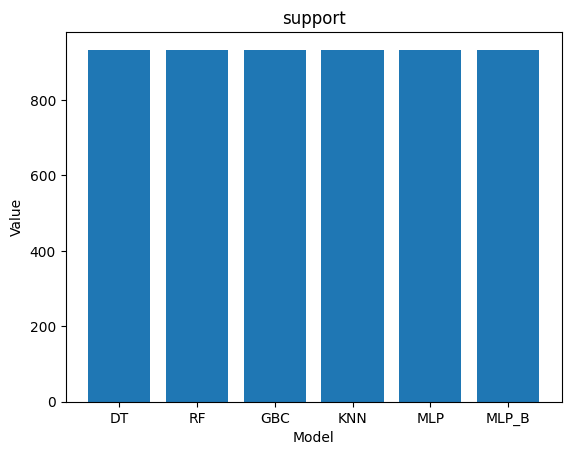

precision
{'DT': 0.9621993127147767, 'RF': 0.962080173347779, 'GBC': 0.9757894736842105, 'KNN': 0.9989247311827957, 'MLP': 0.9925293489861259, 'MLP_B': 0.9978425026968716}


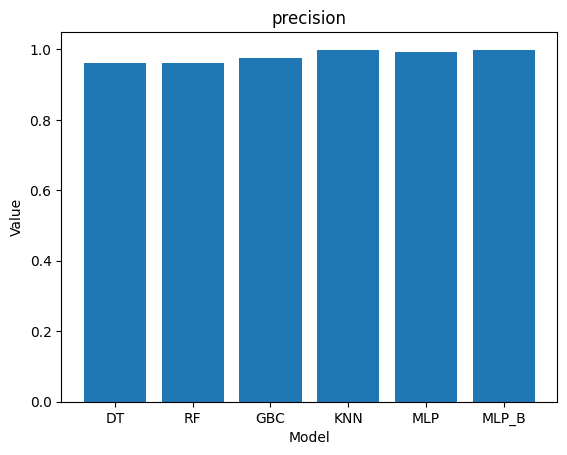

accuracy
{'DT': 0.870236869207003, 'RF': 0.917610710607621, 'GBC': 0.9701338825952626, 'KNN': 0.9948506694129763, 'MLP': 0.9897013388259527, 'MLP_B': 0.9897013388259527}


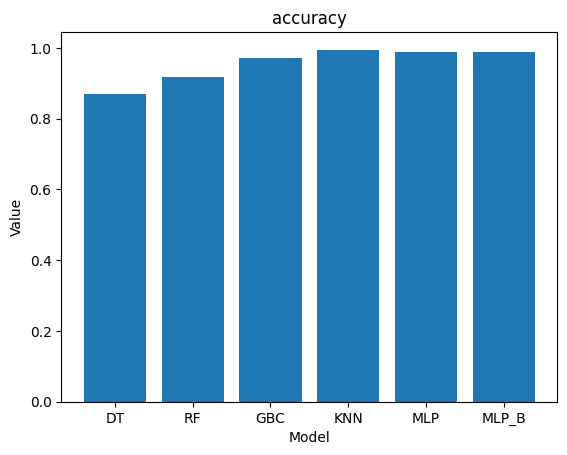

In [79]:
if __name__ == "__main__":
    main()